# ARIMA modeling

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Reading dataset

In [41]:
df = pd.read_csv('../data/MaunaLoaDailyTemps.csv', index_col='DATE', parse_dates=True)
df

,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
DATE,,,,,
2014-01-01,33.0,46.0,40.0,657,1756
2014-01-02,35.0,50.0,43.0,657,1756
2014-01-03,36.0,45.0,41.0,657,1757
2014-01-04,32.0,41.0,37.0,658,1757
2014-01-05,24.0,38.0,31.0,658,1758
...,...,...,...,...,...
2018-12-26,35.0,45.0,40.0,654,1752
2018-12-27,33.0,44.0,39.0,655,1752
2018-12-28,33.0,47.0,40.0,655,1753


## Summarizing dataset

In [42]:
df.describe()

,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
count,1821.000000,1821.000000,1821.000000,1825.000000,1825.000000
mean,38.637013,54.515102,46.818781,607.074521,1823.002740
std,3.798284,5.013654,4.143192,40.797585,49.555065
min,22.000000,36.000000,31.000000,543.000000,1742.000000
25%,36.000000,52.000000,44.000000,557.000000,1802.000000
50%,39.000000,55.000000,47.000000,614.000000,1831.000000
75%,41.000000,58.000000,50.000000,640.000000,1851.000000
max,49.000000,67.000000,57.000000,700.000000,1905.000000


## Meta info of dataset

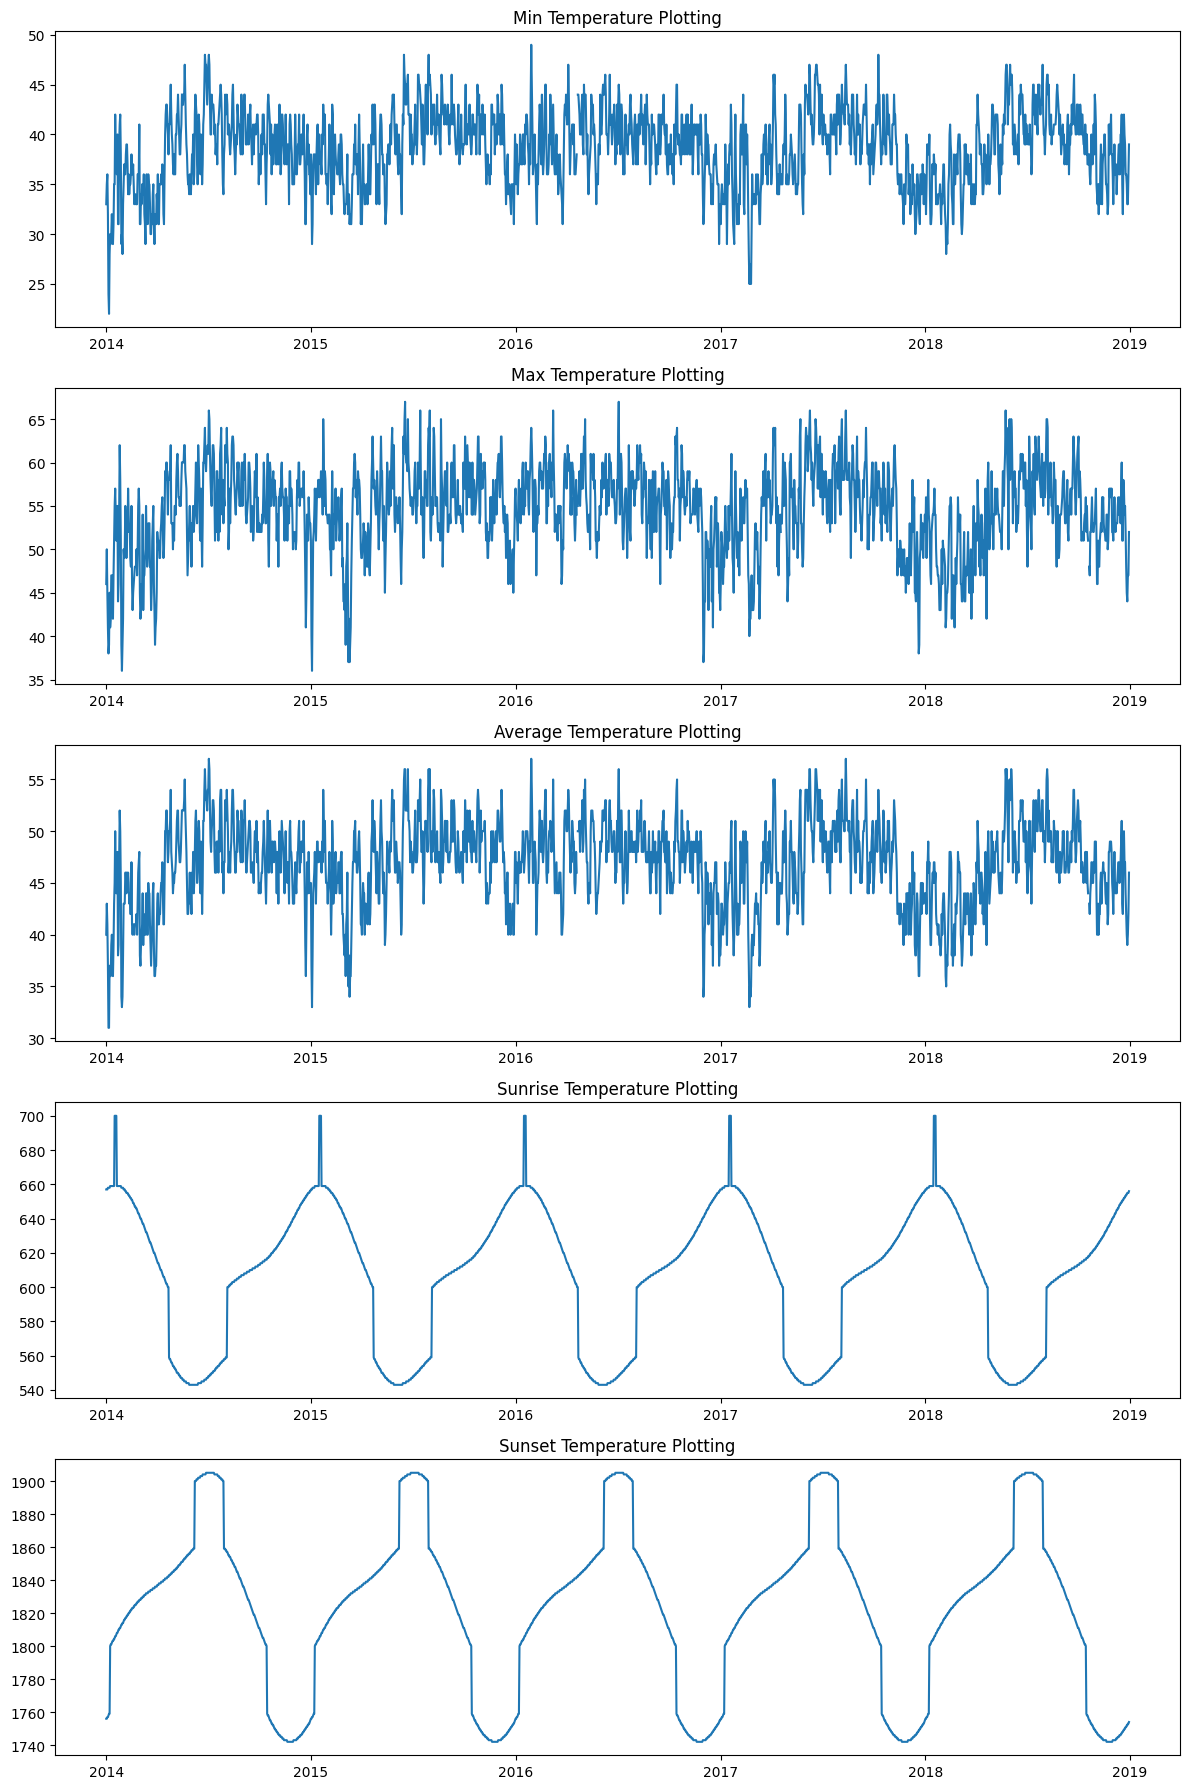

In [43]:
plt.figure(figsize=(12, 18))

plt.subplot(5,1,1)
plt.plot(df['MinTemp'])
plt.title('Min Temperature Plotting')

plt.subplot(5,1,2)
plt.plot(df['MaxTemp'])
plt.title('Max Temperature Plotting')

plt.subplot(5,1,3)
plt.plot(df['AvgTemp'])
plt.title('Average Temperature Plotting')

plt.subplot(5,1,4)
plt.plot(df['Sunrise'])
plt.title('Sunrise Temperature Plotting')

plt.subplot(5,1,5)
plt.plot(df['Sunset'])
plt.title('Sunset Temperature Plotting')

plt.tight_layout()
plt.show()

In [44]:
df.isna(), df.shape

(            MinTemp  MaxTemp  AvgTemp  Sunrise  Sunset
 DATE                                                  
 2014-01-01    False    False    False    False   False
 2014-01-02    False    False    False    False   False
 2014-01-03    False    False    False    False   False
 2014-01-04    False    False    False    False   False
 2014-01-05    False    False    False    False   False
 ...             ...      ...      ...      ...     ...
 2018-12-26    False    False    False    False   False
 2018-12-27    False    False    False    False   False
 2018-12-28    False    False    False    False   False
 2018-12-29    False    False    False    False   False
 2018-12-30    False    False    False    False   False
 
 [1825 rows x 5 columns],
 (1825, 5))

In [45]:
df = df.dropna()
df.shape

(1821, 5)

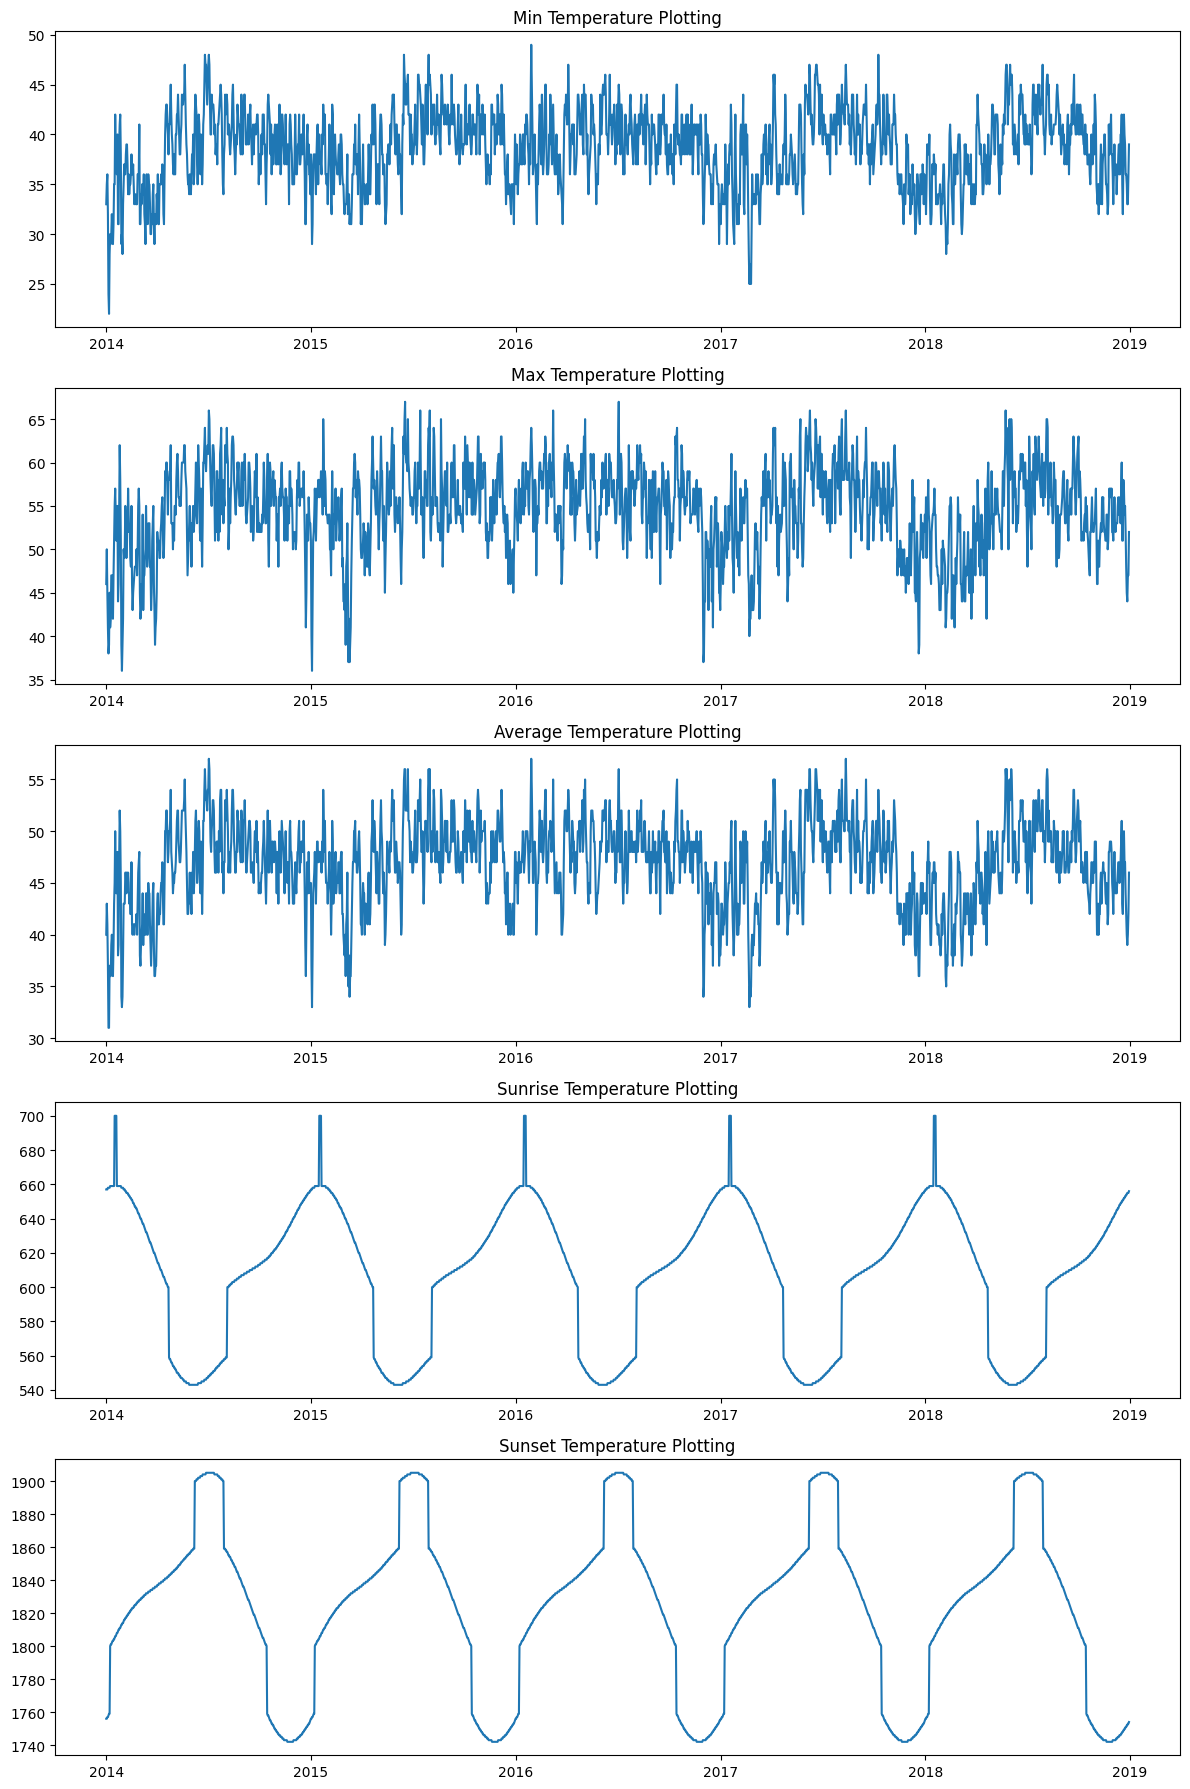

In [46]:
plt.figure(figsize=(12, 18))

plt.subplot(5,1,1)
plt.plot(df['MinTemp'])
plt.title('Min Temperature Plotting')

plt.subplot(5,1,2)
plt.plot(df['MaxTemp'])
plt.title('Max Temperature Plotting')

plt.subplot(5,1,3)
plt.plot(df['AvgTemp'])
plt.title('Average Temperature Plotting')

plt.subplot(5,1,4)
plt.plot(df['Sunrise'])
plt.title('Sunrise Temperature Plotting')

plt.subplot(5,1,5)
plt.plot(df['Sunset'])
plt.title('Sunset Temperature Plotting')

plt.tight_layout()
plt.show()

## Testing stationarity

In [49]:
from numpy.typing import ArrayLike
from statsmodels.tsa.stattools import adfuller

def adf_test(dataset: ArrayLike):
    adf_test_res = adfuller(x=dataset, autolag='AIC')

    print("ADF: ", adf_test_res[0])
    print("P-value: ", adf_test_res[1])
    print("No. of lags: ", adf_test_res[2])
    print("Number of observations used for ADF and critical value calculation: ", adf_test_res[3])
    print("Critical values: ")
    for key, val in adf_test_res[4].items():
        print(f"\t{key} : {val}")

In [50]:
adf_test(df['AvgTemp'])

ADF:  -6.554680125068778
P-value:  8.675937480199557e-09
No. of lags:  12
Number of observations used for ADF and critical value calculation:  1808
Critical values: 
	1% : -3.433972018026501
	5% : -2.8631399192826676
	10% : -2.5676217442756872


## Forecasting

In [51]:
from pmdarima import auto_arima
import warnings

warnings.filterwarnings('ignore')

In [53]:
stepwise_fit_arima = auto_arima(df['AvgTemp'], trace=True, suppress_warnings=True)
stepwise_fit_arima.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=8344.456, Time=5.64 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=10347.755, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=8365.701, Time=0.24 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=9136.225, Time=0.36 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=19192.139, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=8355.947, Time=2.02 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=8356.308, Time=3.26 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=8347.310, Time=3.60 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=8318.028, Time=4.27 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=8330.190, Time=3.40 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=8310.811, Time=4.74 sec
 ARIMA(4,0,3)(0,0,0)[0] intercept   : AIC=8332.047, Time=5.73 sec
 ARIMA(3,0,4)(0,0,0)[0] intercept   : AIC=8317.631, Time=5.84 sec
 ARIMA(2,0,4)(0,0,0)[0] intercept   : AIC=8305.555, Time=4.89 sec
 ARIMA(1,0,4)(0,0,0)[0] interce

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1821
Model:               SARIMAX(1, 0, 5)   Log Likelihood               -4139.921
Date:                Tue, 29 Oct 2024   AIC                           8295.842
Time:                        02:24:46   BIC                           8339.900
Sample:                             0   HQIC                          8312.096
                               - 1821                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.3296      0.385      3.452      0.001       0.575       2.084
ar.L1          0.9714      0.008    117.022      0.000       0.955       0.988
ma.L1         -0.1239      0.024     -5.243      0.000      -0.170      -0.078
ma.L2         -0.2175      0.024     -9.042      0.000      -0.265      -0.170
ma.L3         -0.2022      0.024     -8.510      0.000      -0.249      -0.156
ma.L4         -0.1353      0.023     -5.995      0.000      -0.180      -0.091
ma.L5         -0.0481      0.024     -1.993      0.046      -0.095      -0.001
sigma2         5.4358      0.168     32.313      0.000       5.106       5.766
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                21.24
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.81   Skew:                            -0.17
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [97]:
from statsmodels.tsa.arima.model import ARIMA

train = df.iloc[:30]
test = df.iloc[30:]

In [98]:
train.shape, test.shape

((30, 5), (1791, 5))

In [99]:
model = ARIMA(df['AvgTemp'], order = (1,0,5)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                AvgTemp   No. Observations:                 1821
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -4138.130
Date:                Tue, 29 Oct 2024   AIC                           8292.261
Time:                        04:03:09   BIC                           8336.318
Sample:                             0   HQIC                          8308.514
                               - 1821                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.5285      0.758     61.403      0.000      45.043      48.014
ar.L1          0.9860      0.005    192.909      0.000       0.976       0.996
ma.L1         -0.1403      0.023     -6.125      0.000      -0.185      -0.095
ma.L2         -0.2328      0.023    -10.038      0.000      -0.278      -0.187
ma.L3         -0.2163      0.023     -9.280      0.000      -0.262      -0.171
ma.L4         -0.1478      0.023     -6.542      0.000      -0.192      -0.104
ma.L5         -0.0587      0.024     -2.424      0.015      -0.106      -0.011
sigma2         5.5080      0.173     31.925      0.000       5.170       5.846
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                15.69
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.81   Skew:                            -0.15
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [100]:
forecasts = model.predict(start = len(train), end = len(train) + len(test) - 1, type = 'level', dynamic=False)
forecasts

DATE
2014-01-31    37.339413
2014-02-01    40.445361
2014-02-02    43.804461
2014-02-03    42.833478
2014-02-04    42.678681
                ...    
2018-12-26    43.067257
2018-12-27    41.607901
2018-12-28    40.981616
2018-12-29    41.968533
2018-12-30    43.435178
Name: predicted_mean, Length: 1791, dtype: float64

<Axes: xlabel='DATE'>

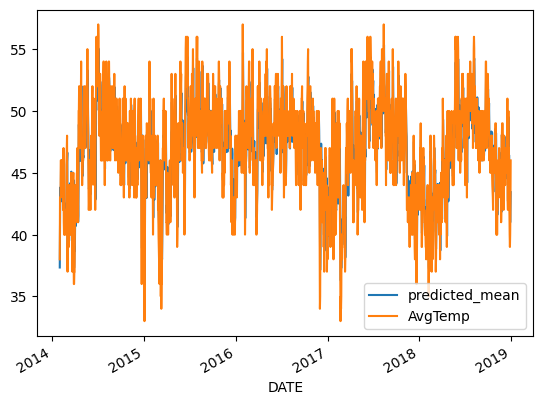

In [101]:
forecasts.plot(legend=True)
test['AvgTemp'].plot(legend=True)

In [103]:
test['AvgTemp'].values

array([38., 43., 43., ..., 40., 42., 46.])

### Error calculation

In [107]:
test['AvgTemp'].mean()

46.92294807370184

In [110]:
from math import sqrt
from sklearn.metrics import mean_squared_error

rmse = sqrt(mean_squared_error(forecasts, test['AvgTemp']))
print("RMSE: ", rmse)

RMSE:  2.309608510383801


### Future modeling with ARIMA

In [111]:
future_model = ARIMA(df['AvgTemp'], order = (1,0,5)).fit()
df.tail(10)

,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
DATE,,,,,
2018-12-21,42.0,57.0,50.0,652,1749
2018-12-22,40.0,54.0,47.0,652,1750
2018-12-23,39.0,55.0,47.0,653,1750
2018-12-24,36.0,52.0,44.0,653,1751
2018-12-25,36.0,48.0,42.0,654,1751
2018-12-26,35.0,45.0,40.0,654,1752
2018-12-27,33.0,44.0,39.0,655,1752
2018-12-28,33.0,47.0,40.0,655,1753
2018-12-29,36.0,47.0,42.0,655,1753


In [112]:
date_index = pd.date_range(start='2018-12-30', end='2019-1-30')
date_index

DatetimeIndex(['2018-12-30', '2018-12-31', '2019-01-01', '2019-01-02',
               '2019-01-03', '2019-01-04', '2019-01-05', '2019-01-06',
               '2019-01-07', '2019-01-08', '2019-01-09', '2019-01-10',
               '2019-01-11', '2019-01-12', '2019-01-13', '2019-01-14',
               '2019-01-15', '2019-01-16', '2019-01-17', '2019-01-18',
               '2019-01-19', '2019-01-20', '2019-01-21', '2019-01-22',
               '2019-01-23', '2019-01-24', '2019-01-25', '2019-01-26',
               '2019-01-27', '2019-01-28', '2019-01-29', '2019-01-30'],
              dtype='datetime64[ns]', freq='D')

In [113]:
future_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                AvgTemp   No. Observations:                 1821
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -4138.130
Date:                Tue, 29 Oct 2024   AIC                           8292.261
Time:                        04:30:15   BIC                           8336.318
Sample:                             0   HQIC                          8308.514
                               - 1821                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.5285      0.758     61.403      0.000      45.043      48.014
ar.L1          0.9860      0.005    192.909      0.000       0.976       0.996
ma.L1         -0.1403      0.023     -6.125      0.000      -0.185      -0.095
ma.L2         -0.2328      0.023    -10.038      0.000      -0.278      -0.187
ma.L3         -0.2163      0.023     -9.280      0.000      -0.262      -0.171
ma.L4         -0.1478      0.023     -6.542      0.000      -0.192      -0.104
ma.L5         -0.0587      0.024     -2.424      0.015      -0.106      -0.011
sigma2         5.5080      0.173     31.925      0.000       5.170       5.846
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                15.69
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.81   Skew:                            -0.15
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [115]:
futuristic_forecasts = future_model.predict(start = len(df), end = len(df) + 31, dynamic=True,type='level').rename('ARIMA predictions')
futuristic_forecasts.index = date_index
futuristic_forecasts

2018-12-30    46.418166
2018-12-31    46.113912
2019-01-01    45.617874
2019-01-02    45.249566
2019-01-03    45.116916
2019-01-04    45.136666
2019-01-05    45.156140
2019-01-06    45.175342
2019-01-07    45.194275
2019-01-08    45.212943
2019-01-09    45.231350
2019-01-10    45.249499
2019-01-11    45.267394
2019-01-12    45.285039
2019-01-13    45.302437
2019-01-14    45.319592
2019-01-15    45.336506
2019-01-16    45.353184
2019-01-17    45.369629
2019-01-18    45.385843
2019-01-19    45.401831
2019-01-20    45.417594
2019-01-21    45.433138
2019-01-22    45.448463
2019-01-23    45.463575
2019-01-24    45.478475
2019-01-25    45.493166
2019-01-26    45.507652
2019-01-27    45.521935
2019-01-28    45.536019
2019-01-29    45.549905
2019-01-30    45.563597
Freq: D, Name: ARIMA predictions, dtype: float64

<Axes: >

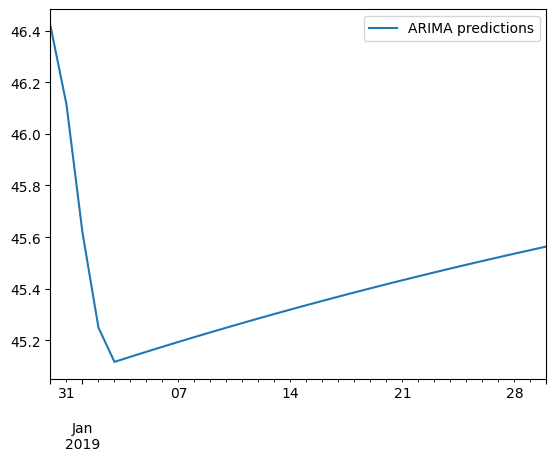

In [116]:
futuristic_forecasts.plot(legend=True)